# Fase 1 — Exploración del Dataset
## Proyecto: Sistema de Predicción de Factores de Riesgo en Adolescentes Salvadoreños
**Dataset:** GSHS 2013 — OMS/OPS El Salvador  
**Cliente ficticio:** Ministerio de Salud (MINSAL)  
**Objetivo de esta fase:**
- Entender la estructura del dataset
- Identificar y corregir el marcador de nulos SPSS
- Analizar las variables demográficas
- Explorar las variables target de Tarea A (IMC) y Tarea B (Salud Mental)

In [ ]:
# ── Librerías ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Silenciar advertencias menores
warnings.filterwarnings("ignore")

# Estilo visual para todas las gráficas del notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Librerías cargadas correctamente ✓")

Matplotlib is building the font cache; this may take a moment.


Librerías cargadas correctamente ✓


## 1. Carga del Dataset

In [2]:
# El marcador de nulo que usa SPSS/Stata al exportar a CSV
MISSING_SPSS = 1.79769313486232e+308

# Ruta relativa al CSV desde la carpeta notebooks/
DATA_PATH = "../data/raw/SLV2013_Public_Use.csv"

# Carga del CSV
df = pd.read_csv(DATA_PATH)

# Contar cuántos marcadores SPSS hay ANTES de limpiar
n_marcadores = (df == MISSING_SPSS).sum().sum()
print(f"Marcadores SPSS encontrados: {n_marcadores:,}")

# Reemplazar por NaN
df.replace(MISSING_SPSS, np.nan, inplace=True)

# Verificar que ya no queda ninguno
n_restantes = (df == MISSING_SPSS).sum().sum()
print(f"Marcadores después de limpiar: {n_restantes}")
print(f"\nDataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Marcadores SPSS encontrados: 0
Marcadores después de limpiar: 0

Dataset cargado: 1,915 filas × 104 columnas


In [5]:
# El marcador está como string en este CSV
# Hay que reemplazarlo como texto primero, luego convertir columnas a numérico

MISSING_STR = "1.79769313486232e+308"

# Reemplazar el string por NaN en todo el dataframe
df.replace(MISSING_STR, np.nan, inplace=True)

# Verificar
n_marcadores = df.isnull().sum().sum()
print(f"NaN después de limpiar: {n_marcadores:,}")

print("\n=== Columnas con más NaN (top 10) ===")
print(df.isnull().sum().sort_values(ascending=False).head(10))

NaN después de limpiar: 23,118

=== Columnas con más NaN (top 10) ===
qnc2g    1784
qnc1g    1731
QN40     1692
QN47     1582
QN48     1580
QN21     1568
QN45     1565
QN37     1552
QN36     1507
QN18     1465
dtype: int64


## 2. Dimensiones y estructura del dataset

In [6]:
# Clasificar las columnas por grupo
cols_q   = [c for c in df.columns if c.startswith('Q') and not c.startswith('QN')]
cols_qn  = [c for c in df.columns if c.startswith('QN')]
cols_der = [c for c in df.columns if c.startswith('qn')]
cols_w   = ['weight', 'stratum', 'psu']

print("=== ESTRUCTURA DEL DATASET ===")
print(f"Total filas    : {df.shape[0]:,}")
print(f"Total columnas : {df.shape[1]}")
print(f"\nGrupo Q  (preguntas originales) : {len(cols_q)} columnas")
print(f"Grupo QN (recodificaciones OPS) : {len(cols_qn)} columnas")
print(f"Grupo qn (indicadores derivados): {len(cols_der)} columnas")
print(f"Muestreo (weight/stratum/psu)   : {len(cols_w)} columnas")

print(f"\n% de datos nulos global: {df.isnull().mean().mean()*100:.2f}%")

=== ESTRUCTURA DEL DATASET ===
Total filas    : 1,915
Total columnas : 104

Grupo Q  (preguntas originales) : 49 columnas
Grupo QN (recodificaciones OPS) : 44 columnas
Grupo qn (indicadores derivados): 8 columnas
Muestreo (weight/stratum/psu)   : 3 columnas

% de datos nulos global: 11.61%


## 3. Variables demográficas

In [11]:
# Columnas que NO deben convertirse (ya son correctas)
cols_no_convertir = ['edad_label', 'sexo_label']

# Convertir todo lo demás a numérico
for col in df.columns:
    if col not in cols_no_convertir:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Verificar que Q1 ahora es numérico
print("Tipo de Q1 después de convertir:", df["Q1"].dtype)
print("Primeros 10 valores:", df["Q1"].head(10).tolist())

print(f"\nNaN totales ahora: {df.isnull().sum().sum():,}")

Tipo de Q1 después de convertir: float64
Primeros 10 valores: [4.0, 3.0, 4.0, 5.0, 3.0, 4.0, 4.0, 4.0, 3.0, 3.0]

NaN totales ahora: 26,948


In [12]:
# Ahora que Q1 y Q2 son float, el map funciona correctamente
edad_map = {1.0:"≤11", 2.0:"12", 3.0:"13", 4.0:"14", 5.0:"15", 6.0:"≥16"}
sexo_map = {1.0:"Masculino", 2.0:"Femenino"}

df["edad_label"] = df["Q1"].map(edad_map)
df["sexo_label"] = df["Q2"].map(sexo_map)

print("=== DISTRIBUCIÓN DE EDAD (Q1) ===")
print(df["edad_label"].value_counts().sort_index())

print("\n=== DISTRIBUCIÓN DE SEXO (Q2) ===")
print(df["sexo_label"].value_counts())

=== DISTRIBUCIÓN DE EDAD (Q1) ===
edad_label
12      45
13     350
14     665
15     555
≤11      8
≥16    263
Name: count, dtype: int64

=== DISTRIBUCIÓN DE SEXO (Q2) ===
sexo_label
Masculino    1013
Femenino      870
Name: count, dtype: int64


### Visualización de variables demográficas

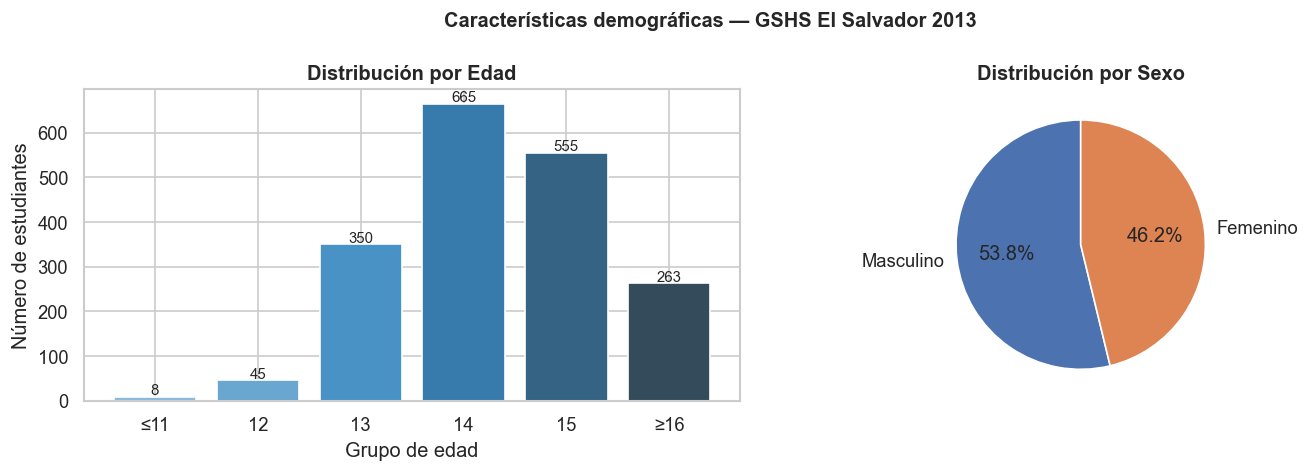

Figura guardada en reports/figures/


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Gráfica 1: Distribución de edad ---
orden_edad = ["≤11", "12", "13", "14", "15", "≥16"]
edad_counts = df["edad_label"].value_counts().reindex(orden_edad)

axes[0].bar(
    orden_edad,
    edad_counts.values,
    color=sns.color_palette("Blues_d", len(orden_edad))
)
axes[0].set_title("Distribución por Edad", fontweight="bold")
axes[0].set_xlabel("Grupo de edad")
axes[0].set_ylabel("Número de estudiantes")
for i, v in enumerate(edad_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

# --- Gráfica 2: Distribución por sexo ---
sexo_counts = df["sexo_label"].value_counts()
axes[1].pie(
    sexo_counts.values,
    labels=sexo_counts.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90
)
axes[1].set_title("Distribución por Sexo", fontweight="bold")

plt.suptitle("Características demográficas — GSHS El Salvador 2013",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/fig1_demograficos.png", bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")

## 4. Tarea A — Variable Target: IMC
El IMC (Índice de Masa Corporal) es la variable que el modelo de regresión
deberá predecir. Se calcula con la fórmula:

**IMC = peso (kg) / estatura (m)²**

- Q4 = estatura en metros
- Q5 = peso en kilogramos

⚠️ Q4 y Q5 se usarán SOLO para calcular el IMC.
No pueden usarse como features del modelo — eso sería data leakage.

In [14]:
# Calcular IMC
df["IMC"] = df["Q5"] / (df["Q4"] ** 2)

print("=== ESTADÍSTICAS DEL IMC ===")
print(df["IMC"].describe().round(2))

print(f"\nRegistros con IMC calculado : {df['IMC'].notna().sum()}")
print(f"Registros sin IMC (Q4 o Q5 nulo): {df['IMC'].isna().sum()}")

# Clasificación OMS simplificada
def clasificar_imc(imc):
    if pd.isna(imc):   return np.nan
    if imc < 18.5:     return "Bajo peso"
    if imc < 25.0:     return "Normal"
    if imc < 30.0:     return "Sobrepeso"
    return "Obesidad"

df["imc_cat"] = df["IMC"].apply(clasificar_imc)

print("\n=== CATEGORÍAS IMC (OMS) ===")
print(df["imc_cat"].value_counts())

=== ESTADÍSTICAS DEL IMC ===
count    1738.00
mean       21.64
std         4.14
min        13.79
25%        18.77
50%        20.71
75%        23.44
max        46.78
Name: IMC, dtype: float64

Registros con IMC calculado : 1738
Registros sin IMC (Q4 o Q5 nulo): 177

=== CATEGORÍAS IMC (OMS) ===
imc_cat
Normal       1071
Bajo peso     370
Sobrepeso     215
Obesidad       82
Name: count, dtype: int64


### Visualización del IMC

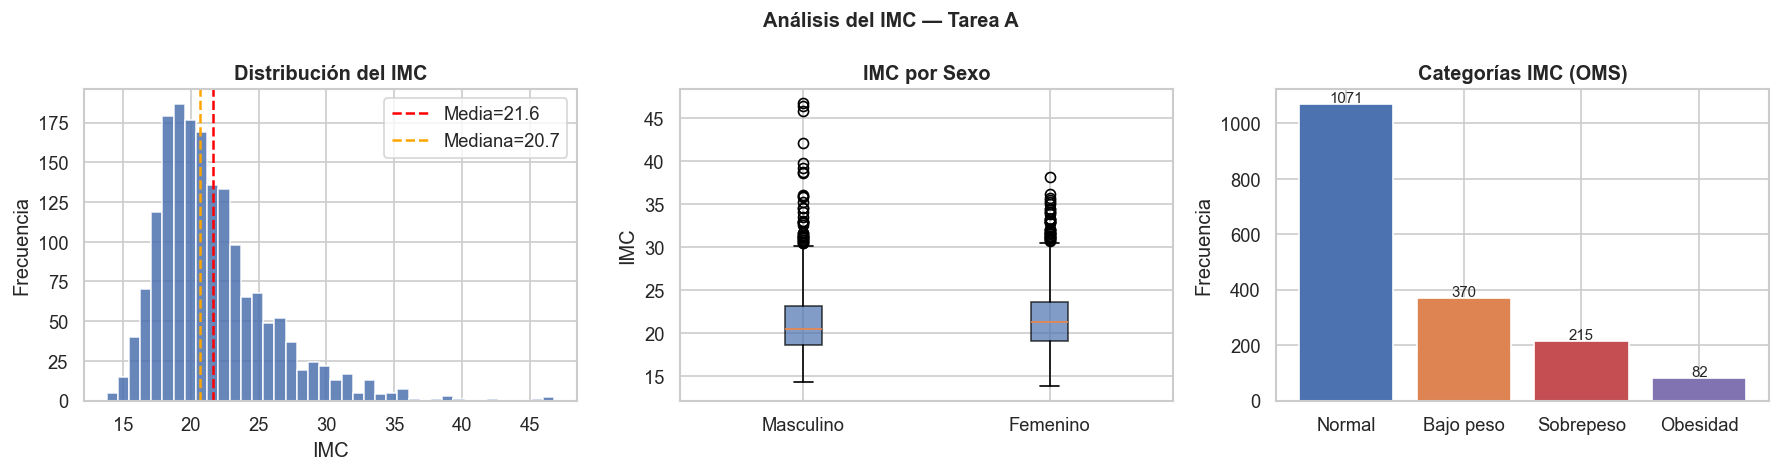

Figura guardada en reports/figures/


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Gráfica 1: Histograma IMC ---
axes[0].hist(df["IMC"].dropna(), bins=40,
             color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["IMC"].mean(), color="red",
                linestyle="--", label=f"Media={df['IMC'].mean():.1f}")
axes[0].axvline(df["IMC"].median(), color="orange",
                linestyle="--", label=f"Mediana={df['IMC'].median():.1f}")
axes[0].set_title("Distribución del IMC", fontweight="bold")
axes[0].set_xlabel("IMC")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Gráfica 2: IMC por sexo ---
masculino = df[df["sexo_label"]=="Masculino"]["IMC"].dropna()
femenino  = df[df["sexo_label"]=="Femenino"]["IMC"].dropna()

axes[1].boxplot(
    [masculino, femenino],
    labels=["Masculino", "Femenino"],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.7)
)
axes[1].set_title("IMC por Sexo", fontweight="bold")
axes[1].set_ylabel("IMC")

# --- Gráfica 3: Categorías IMC ---
cat_counts = df["imc_cat"].value_counts()
colores = {"Normal":"#4C72B0", "Bajo peso":"#DD8452",
           "Sobrepeso":"#C44E52", "Obesidad":"#8172B2"}
axes[2].bar(
    cat_counts.index,
    cat_counts.values,
    color=[colores[c] for c in cat_counts.index]
)
axes[2].set_title("Categorías IMC (OMS)", fontweight="bold")
axes[2].set_ylabel("Frecuencia")
for i, v in enumerate(cat_counts.values):
    axes[2].text(i, v + 5, str(v), ha="center", fontsize=9)

plt.suptitle("Análisis del IMC — Tarea A", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/fig2_imc.png", bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")

## 5. Tarea B — Variable Target: Riesgo Salud Mental

Para la clasificación necesitamos una variable binaria (0/1) que represente
riesgo grave de salud mental.

**Variable elegida: QN26**
- Pregunta original Q26: "¿Cuántos días en los últimos 12 meses te sentiste
  tan triste o desesperanzado que dejaste de hacer tus actividades habituales?"
- QN26 es la recodificación binaria oficial de la OPS:
  - 1 = Sí tuvo ese sentimiento (RIESGO)
  - 2 = No lo tuvo (SIN RIESGO)

**¿Por qué QN26 y no Q26?**
Porque la OPS ya definió el umbral clínico. No necesitamos decidir
nosotros cuántos días constituyen "riesgo" — usamos el criterio oficial.

In [16]:
print("=== Q26 (escala original 1-5) ===")
print(df["Q26"].value_counts().sort_index())

print("\n=== QN26 (recodificación binaria OPS) ===")
print(df["QN26"].value_counts().sort_index())

# Crear variable target binaria: 1=Riesgo, 0=Sin riesgo
df["Riesgo_Salud_Mental"] = df["QN26"].map({1.0: 1, 2.0: 0})

n_riesgo  = df["Riesgo_Salud_Mental"].sum()
n_total   = df["Riesgo_Salud_Mental"].notna().sum()
pct       = n_riesgo / n_total * 100

print("\n=== TARGET: Riesgo_Salud_Mental ===")
print(f"Clase 1 (Riesgo)     : {int(n_riesgo):,}  ({pct:.1f}%)")
print(f"Clase 0 (Sin riesgo) : {int(n_total - n_riesgo):,}  ({100-pct:.1f}%)")
print(f"Nulos                : {df['Riesgo_Salud_Mental'].isna().sum()}")
print(f"\nDesbalance: {(n_total - n_riesgo)/n_riesgo:.1f}:1  (mayoría:minoría)")

# Prevalencia por sexo
print("\n=== PREVALENCIA POR SEXO ===")
prev_sexo = df.groupby("sexo_label")["Riesgo_Salud_Mental"].mean() * 100
print(prev_sexo.round(1).to_string())

=== Q26 (escala original 1-5) ===
Q26
1.0    1651
2.0     157
3.0      58
4.0      20
5.0      20
Name: count, dtype: int64

=== QN26 (recodificación binaria OPS) ===
QN26
1.0     255
2.0    1651
Name: count, dtype: int64

=== TARGET: Riesgo_Salud_Mental ===
Clase 1 (Riesgo)     : 255  (13.4%)
Clase 0 (Sin riesgo) : 1,651  (86.6%)
Nulos                : 9

Desbalance: 6.5:1  (mayoría:minoría)

=== PREVALENCIA POR SEXO ===
sexo_label
Femenino     17.7
Masculino     9.2


### Visualización del Target — Riesgo Salud Mental

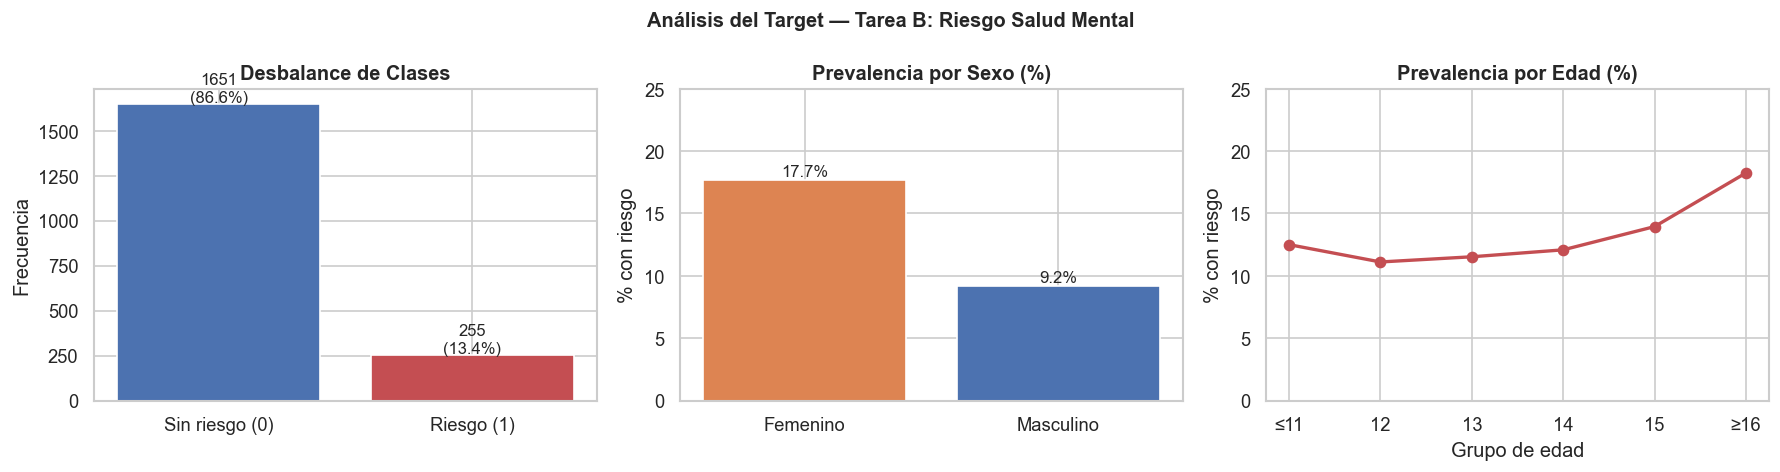

Figura guardada en reports/figures/


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Gráfica 1: Desbalance de clases ---
clases = ["Sin riesgo (0)", "Riesgo (1)"]
valores = [int(n_total - n_riesgo), int(n_riesgo)]
axes[0].bar(clases, valores, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Desbalance de Clases", fontweight="bold")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(valores):
    axes[0].text(i, v + 10, f"{v}\n({v/n_total*100:.1f}%)",
                 ha="center", fontsize=10)

# --- Gráfica 2: Prevalencia por sexo ---
axes[1].bar(
    prev_sexo.index,
    prev_sexo.values,
    color=["#DD8452", "#4C72B0"]
)
axes[1].set_title("Prevalencia por Sexo (%)", fontweight="bold")
axes[1].set_ylabel("% con riesgo")
axes[1].set_ylim(0, 25)
for i, v in enumerate(prev_sexo.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)

# --- Gráfica 3: Prevalencia por edad ---
prev_edad = df.groupby("edad_label")["Riesgo_Salud_Mental"].mean() * 100
orden_edad = ["≤11", "12", "13", "14", "15", "≥16"]
prev_edad = prev_edad.reindex(
    [e for e in orden_edad if e in prev_edad.index]
)
axes[2].plot(prev_edad.index, prev_edad.values,
             marker="o", color="#C44E52", linewidth=2)
axes[2].set_title("Prevalencia por Edad (%)", fontweight="bold")
axes[2].set_ylabel("% con riesgo")
axes[2].set_xlabel("Grupo de edad")
axes[2].set_ylim(0, 25)

plt.suptitle("Análisis del Target — Tarea B: Riesgo Salud Mental",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/fig3_salud_mental.png", bbox_inches="tight")
plt.show()
print("Figura guardada en reports/figures/")

## 6. Resumen Ejecutivo — Hallazgos Fase 1

In [18]:
print("=" * 55)
print("RESUMEN EJECUTIVO — FASE 1")
print("=" * 55)

print("""
DATASET:
  • 1,915 estudiantes, 104 variables
  • Marcador SPSS almacenado como string — corregido a NaN
  • 26,948 valores nulos (11.61% del total)
  • Nulos concentrados en columnas QN (algunas >80%)

DEMOGRAFÍA:
  • Edad predominante: 14 años (665 estudiantes, 34.7%)
  • Sexo: 1,013 masculino (52.9%) / 870 femenino (45.4%)

TAREA A — IMC:
  • IMC calculado para 1,738 registros (177 sin dato)
  • Media: 21.64 | Mediana: 20.71
  • Normal: 61.6% | Bajo peso: 21.3% (alerta MINSAL)
  • Sobrepeso: 12.4% | Obesidad: 4.7%
  • Q4 y Q5 EXCLUIDAS de features (evitar data leakage)

TAREA B — RIESGO SALUD MENTAL (QN26):
  • Clase 1 (riesgo): 255 estudiantes (13.4%)
  • Desbalance 6.5:1 → SMOTE obligatorio en Fase 5
  • Mujeres duplican a hombres: 17.7% vs 9.2%
  • 9 nulos en el target → eliminar en Fase 2
""")

print("FIGURAS GENERADAS:")
print("  reports/figures/fig1_demograficos.png")
print("  reports/figures/fig2_imc.png")
print("  reports/figures/fig3_salud_mental.png")

print("\n[FASE 1 COMPLETADA] ✓")

RESUMEN EJECUTIVO — FASE 1

DATASET:
  • 1,915 estudiantes, 104 variables
  • Marcador SPSS almacenado como string — corregido a NaN
  • 26,948 valores nulos (11.61% del total)
  • Nulos concentrados en columnas QN (algunas >80%)

DEMOGRAFÍA:
  • Edad predominante: 14 años (665 estudiantes, 34.7%)
  • Sexo: 1,013 masculino (52.9%) / 870 femenino (45.4%)

TAREA A — IMC:
  • IMC calculado para 1,738 registros (177 sin dato)
  • Media: 21.64 | Mediana: 20.71
  • Normal: 61.6% | Bajo peso: 21.3% (alerta MINSAL)
  • Sobrepeso: 12.4% | Obesidad: 4.7%
  • Q4 y Q5 EXCLUIDAS de features (evitar data leakage)

TAREA B — RIESGO SALUD MENTAL (QN26):
  • Clase 1 (riesgo): 255 estudiantes (13.4%)
  • Desbalance 6.5:1 → SMOTE obligatorio en Fase 5
  • Mujeres duplican a hombres: 17.7% vs 9.2%
  • 9 nulos en el target → eliminar en Fase 2

FIGURAS GENERADAS:
  reports/figures/fig1_demograficos.png
  reports/figures/fig2_imc.png
  reports/figures/fig3_salud_mental.png

[FASE 1 COMPLETADA] ✓
